# 240907 Revision 8 soil experiment, before rewetting (Griess assay)
- Analysis: Kiseok Lee
- Date: 9/11/24, experiment and measurement of 240901 - 240905 (5 days each)
- Testing Question: N dynamics before rewetting

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('./custom_functions')
import pandas as pd
import numpy as np
import griess as gr
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import importlib

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

## Make output directory



In [2]:
newpath = r'20241103'
if not os.path.exists(newpath):
    os.makedirs(newpath)

## 1. Standard curves with griess assay

## 1.1. 2M KCl based standard curves (not from 10/6/21 stock)

### (1) Using bubble removal using well scan (well quadrant bubble correction)

20241103/standard_metadata.csv
None
20241103/20241103_Ik_NO2_standard_540.CSV
20241103/20241103_Ik_NO2_standard_900.CSV
20241103/20241103_Ik_NO2NO3_standard_540.CSV
20241103/20241103_Ik_NO2NO3_standard_900.CSV
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0057           0.0128    0.4481    0.6565
1        2.2526           0.0477   47.2666    0.0000
2       -0.1070           0.0251   -4.2686    0.0001


 (From statsmodel package) Coefficients are a bit differe

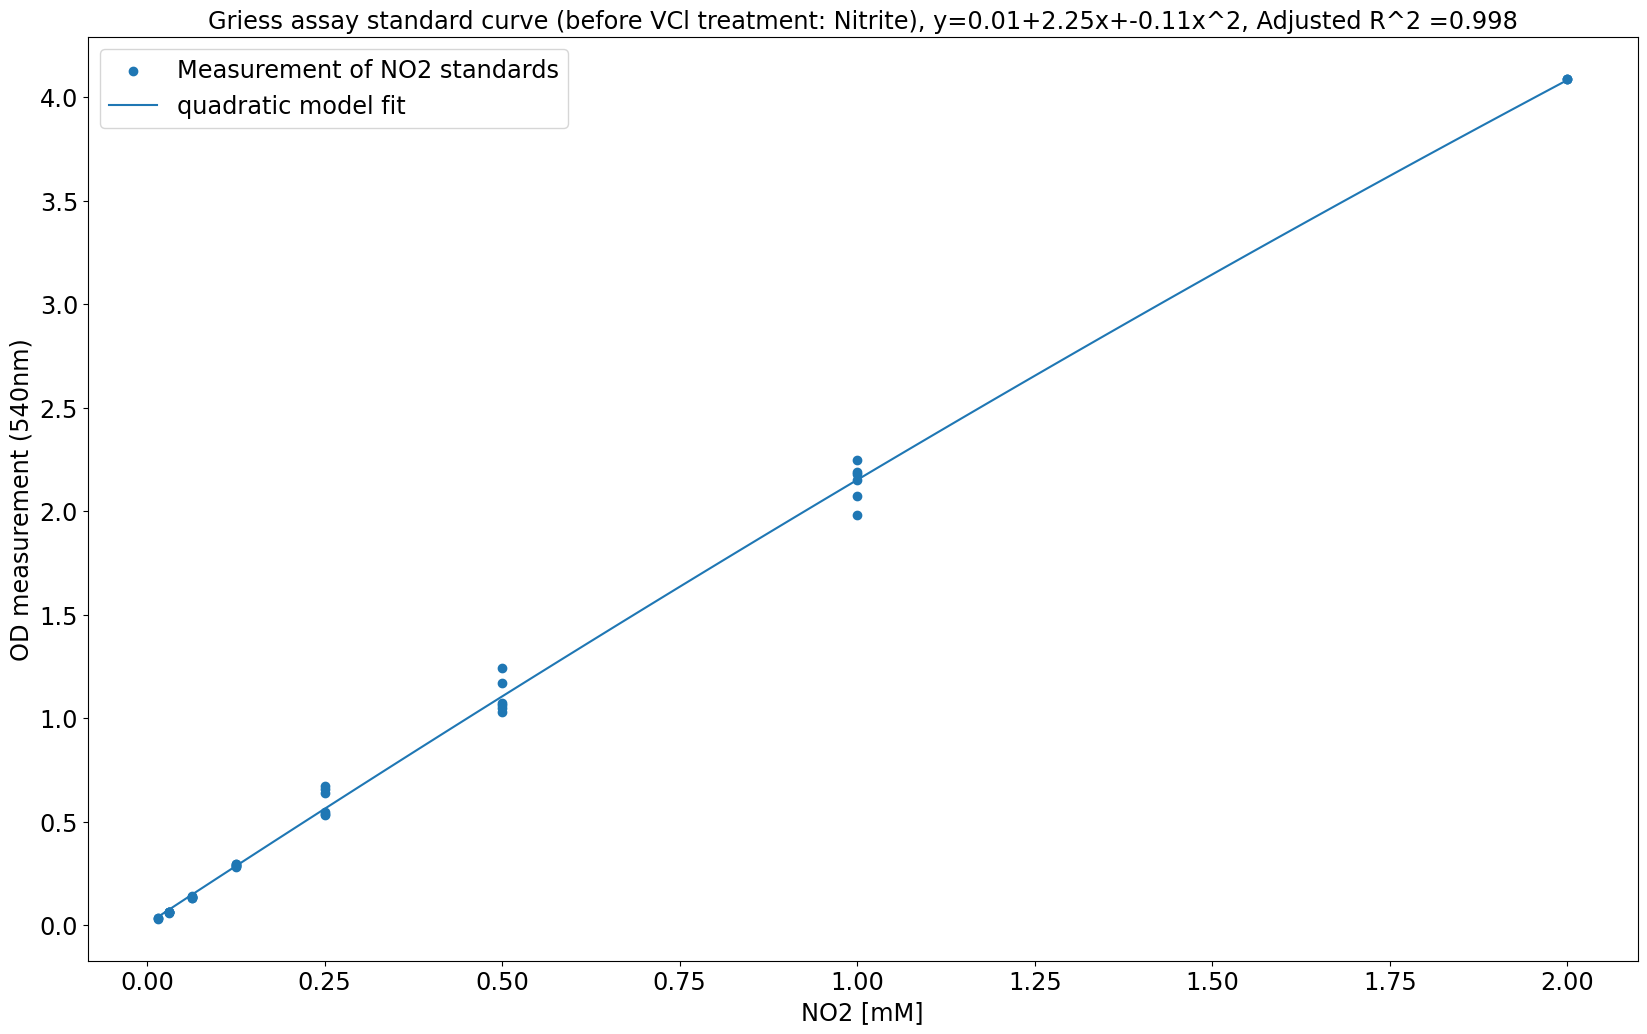

In [4]:
#fit griess assay model using standard curves
std_meta_fn = "20241103/standard_metadata.csv"
print(std_meta_fn)
std_no2_fn = None
print(std_no2_fn)
std_no2_540_fn = glob.glob("20241103/20241103_Ik_NO2_standard_540.CSV")[0]
print(std_no2_540_fn)
std_no2_900_fn = glob.glob("20241103/20241103_Ik_NO2_standard_900.CSV")[0]
print(std_no2_900_fn)

std_no2no3_fn = None
std_no2no3_540_fn = glob.glob("20241103/20241103_Ik_NO2NO3_standard_540.CSV")[0]
print(std_no2no3_540_fn)
std_no2no3_900_fn = glob.glob("20241103/20241103_Ik_NO2NO3_standard_900.CSV")[0]
print(std_no2no3_900_fn)

# plot standard curve
gr.plot_griess_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_standard_curve_with_bubble_removal.png')

# fitted parameters
fit_list = gr.fit_griess(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit, no3_fit] = fit_list


Load standard curve

### (2) After VCl treatment (nitrate reduction to nitrite)

[np.float64(0.003969117403543998), np.float64(1.2215902948267165), np.float64(-0.10284133401532919)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0040           0.0076    0.5190    0.6052
1        1.2216           0.0268   45.6202    0.0000
2       -0.1028           0.0130   -7.8878    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          2.034e+04
Da

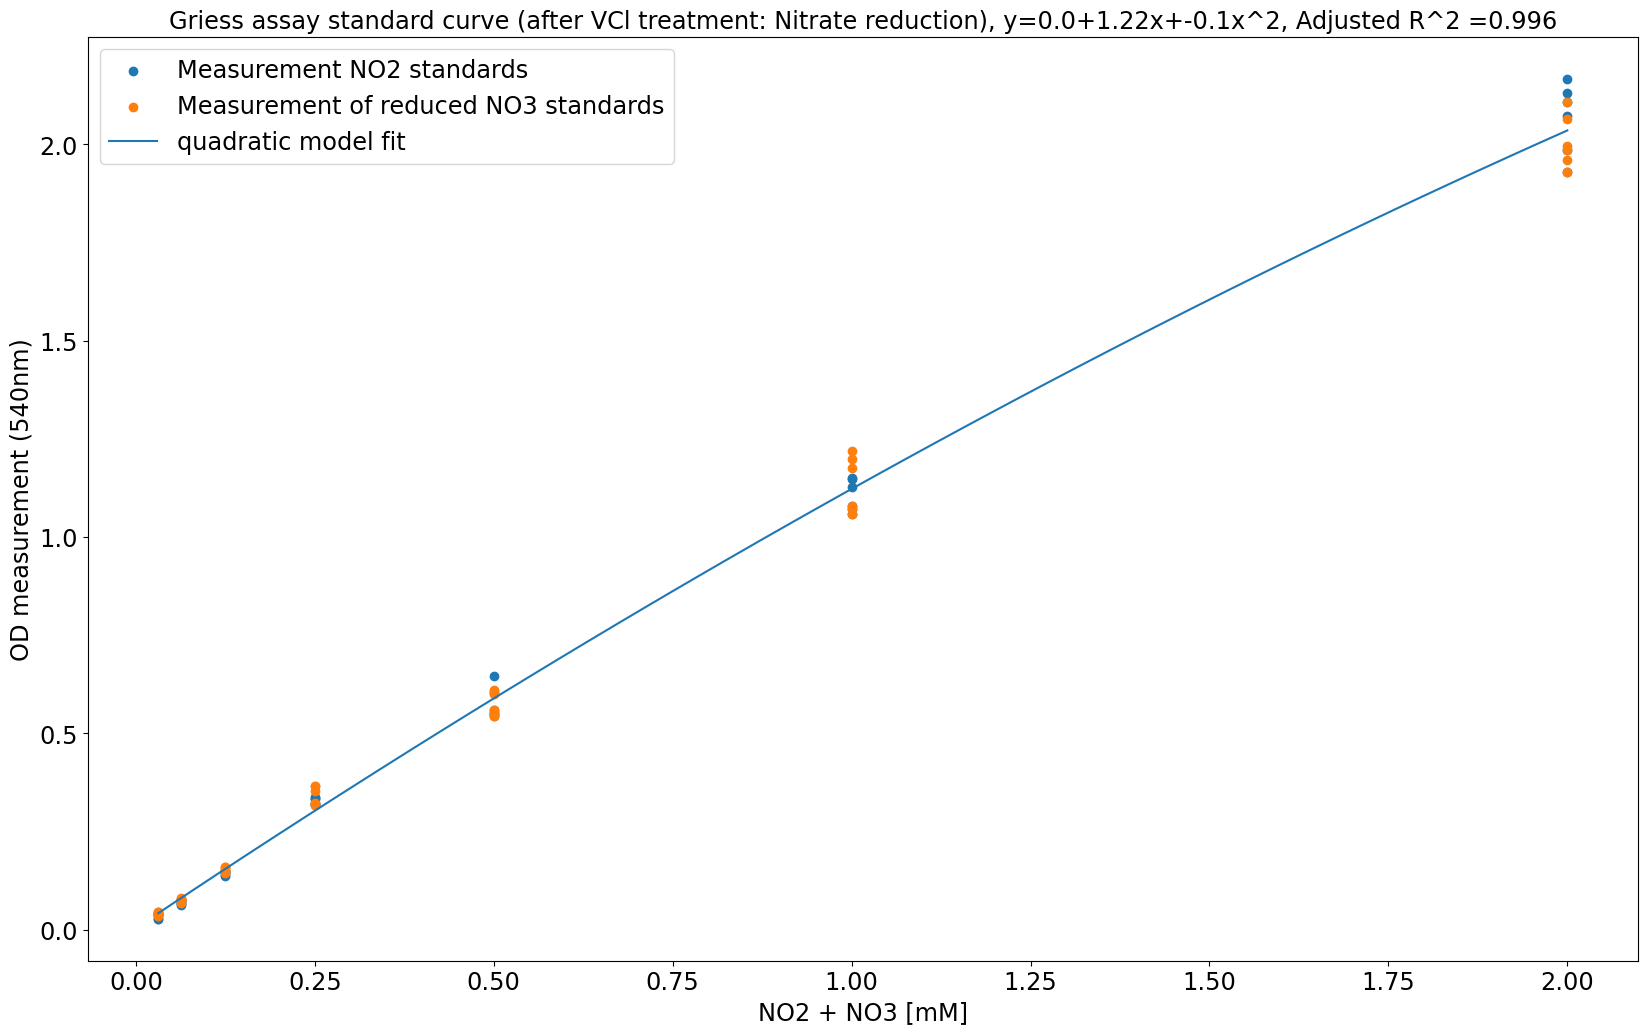

In [5]:
plt.cla()
print(v_fit)

gr.plot_vcl_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_vcl_treated_standard_curve.png')

### (3) Checking the known concentration and the predicted concentration of the NO2-, NO3- mixed standards

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


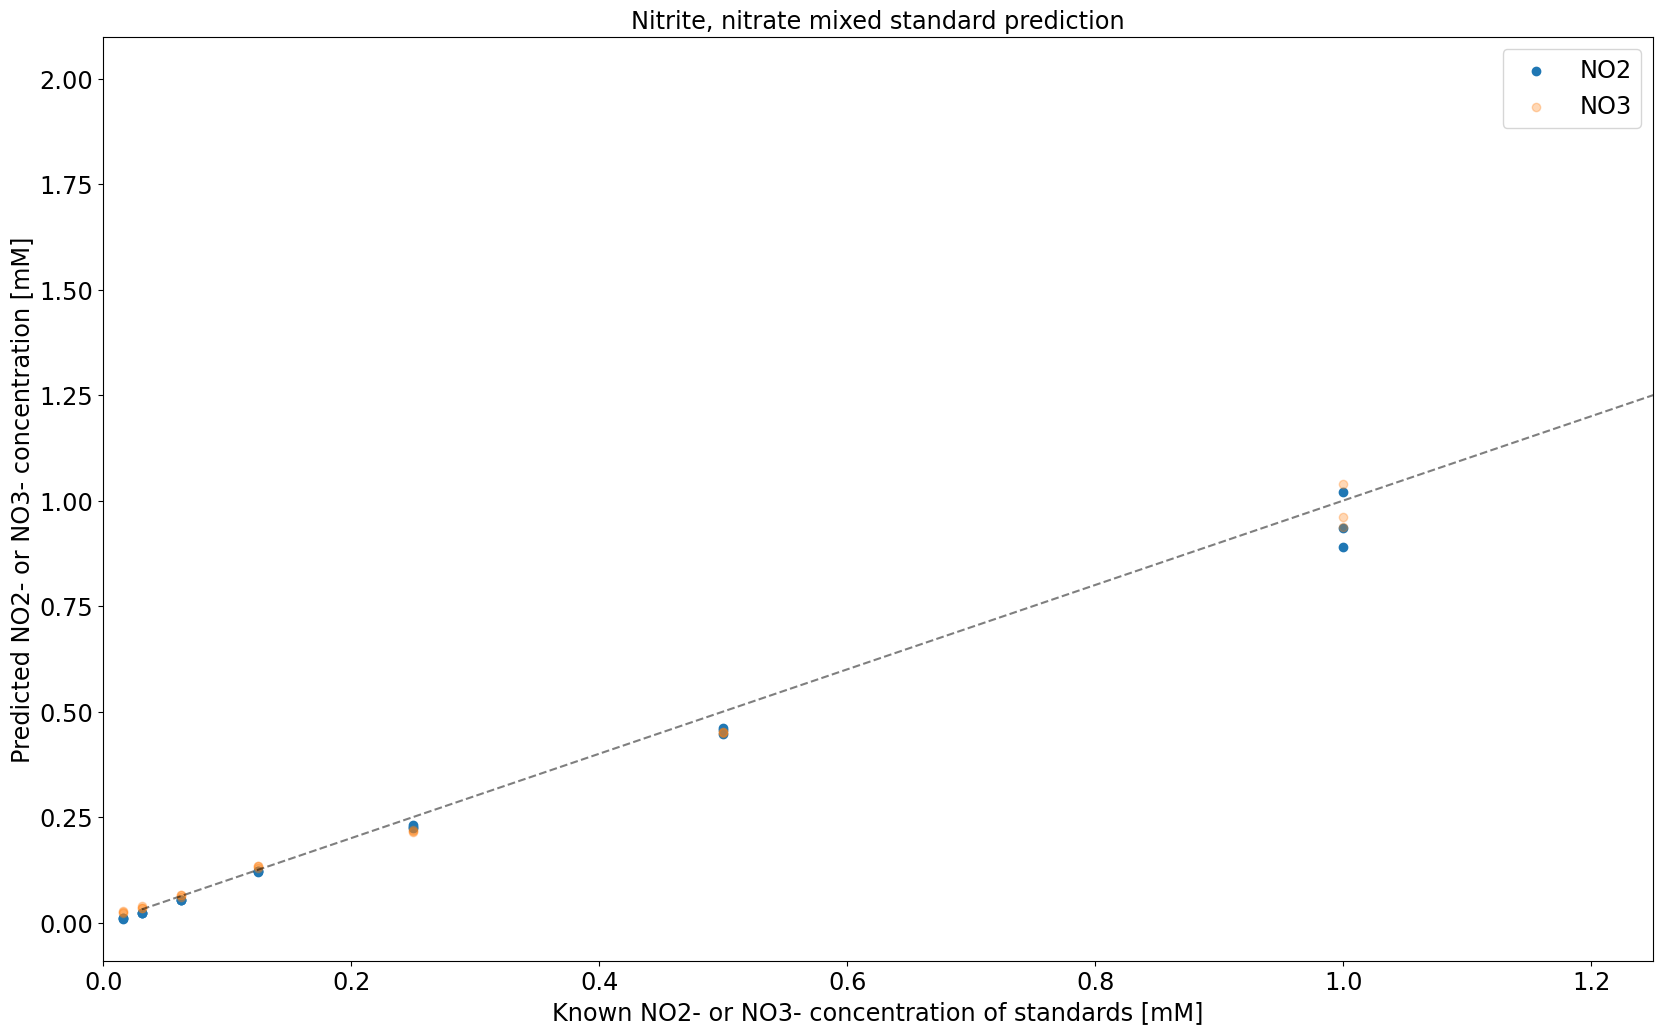

In [6]:
# check mixed conditions prediction
importlib.reload(dn)
gr.plot_mixed_standard_predict(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_mixed_prediction.png')

### (4) Only use nitrate standards for fitting the curve

[np.float64(-0.00349335154826913), np.float64(1.3744829460444734), np.float64(-0.18437232780810833)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0035           0.0100   -0.3488    0.7311
1        1.3745           0.0351   39.1960    0.0000
2       -0.1844           0.0171  -10.7983    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          1.256e+04
Da

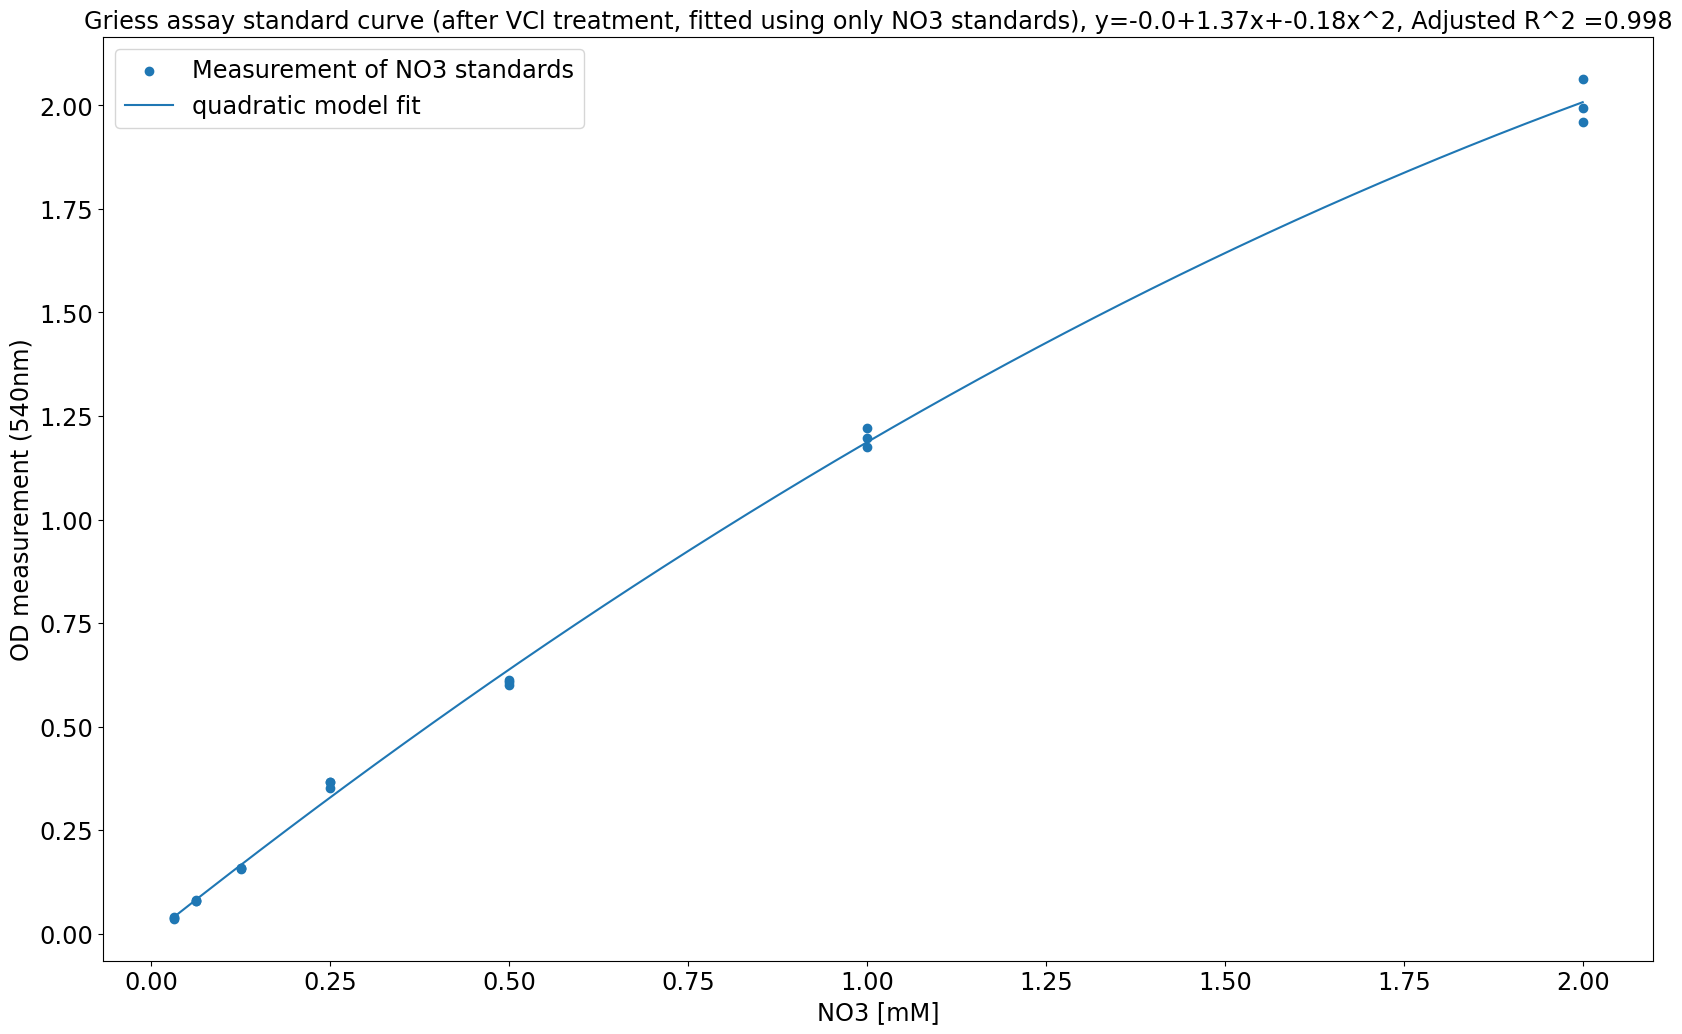

In [7]:
print(no3_fit)

gr.plot_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_vcl_treated_standard_curve_only_using_NO3_standards.png')

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


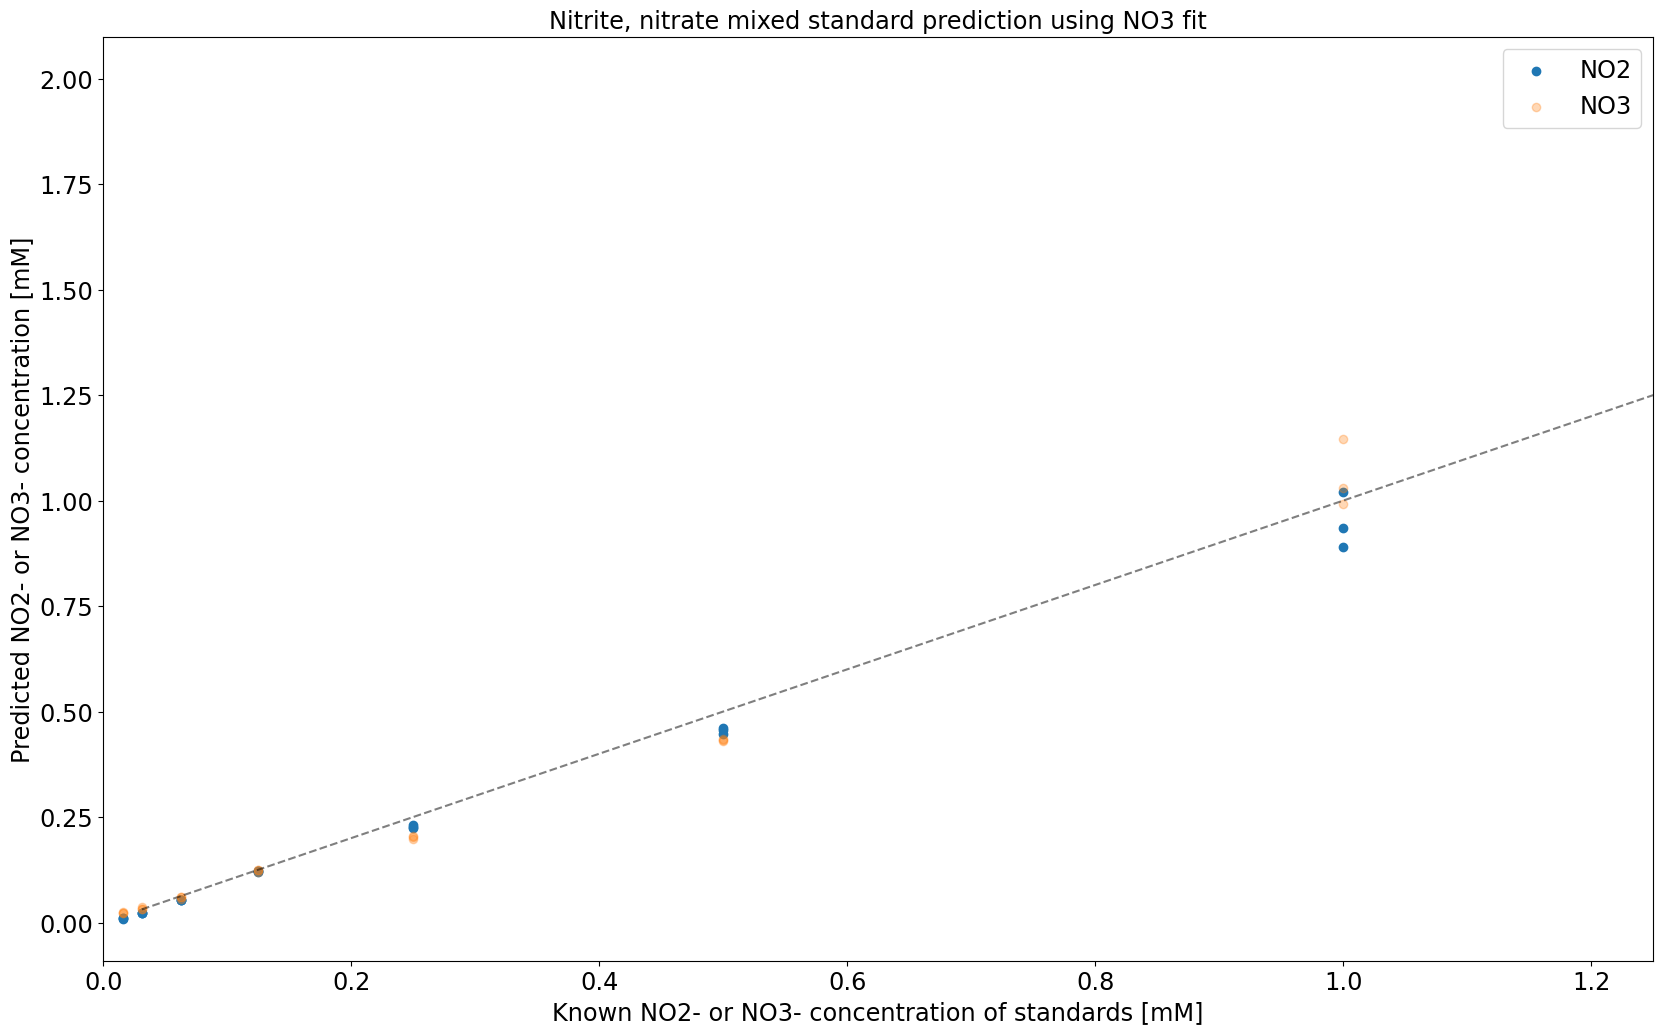

In [8]:
gr.plot_mixed_standard_predict_with_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_mixed_prediction_using_no3_fit.png')

## Make sure that the wellscan is removing all outliers from our data.

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 250 kB 3.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
20241103/sample_metadata.csv
None
20241103/20241103_Ik_NO2_tp0_540.CSV
20241103/20241103_Ik_NO2_tp0_900.CSV
None
20241103/20241103_Ik_NO2NO3_tp0_540.CSV
20241103/20241103_Ik_NO2NO3_tp0_900.CSV
Check wellscan for outlier removal in NO2
returns true for elements more than 1.5 interquartile ranges above the upper quartile


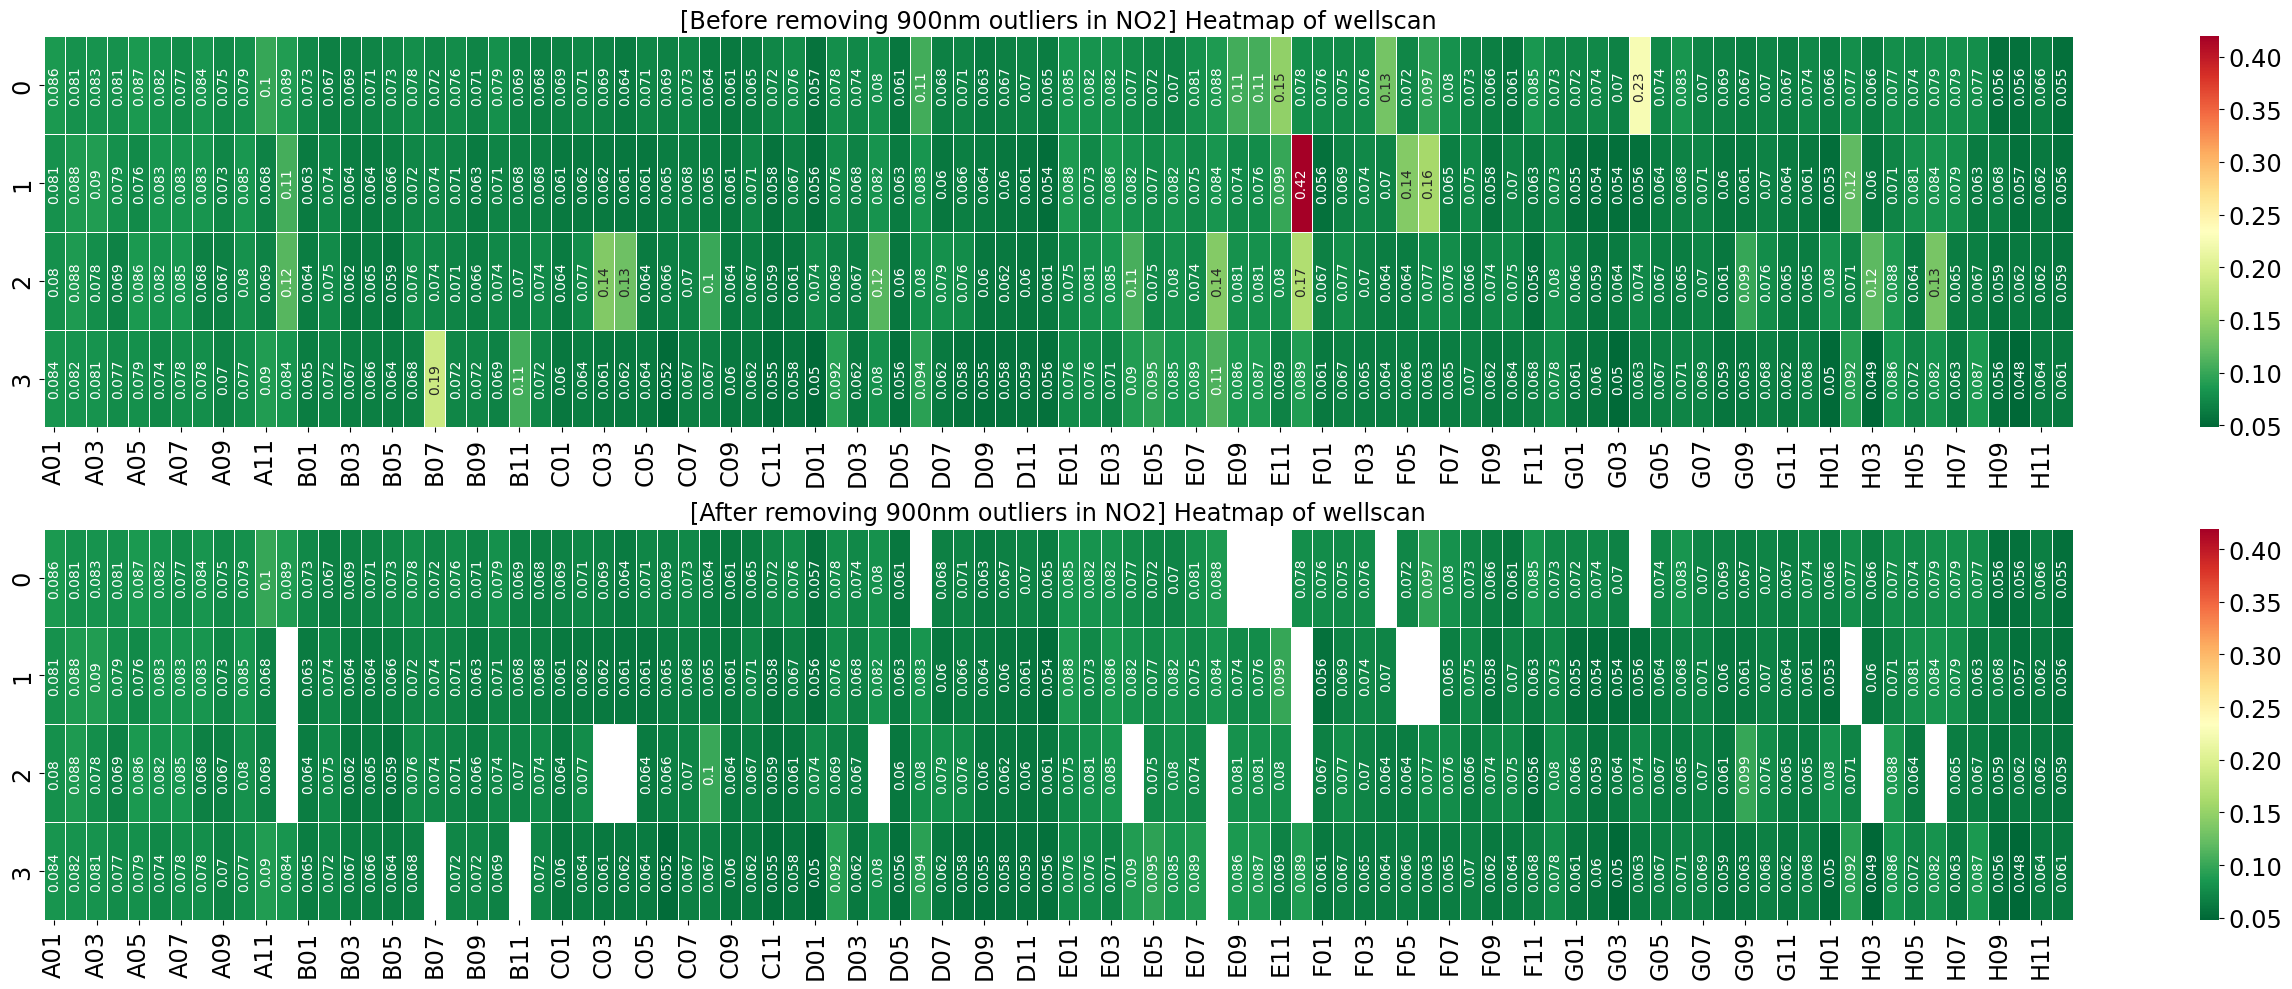

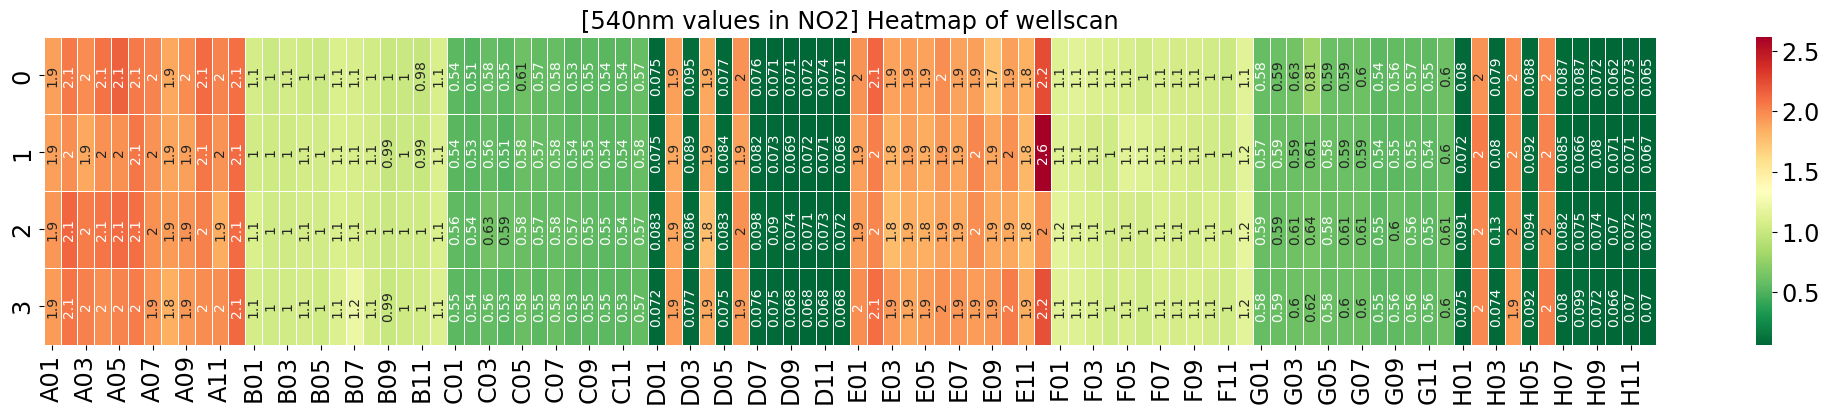

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1.5 interquartile ranges above the upper quartile


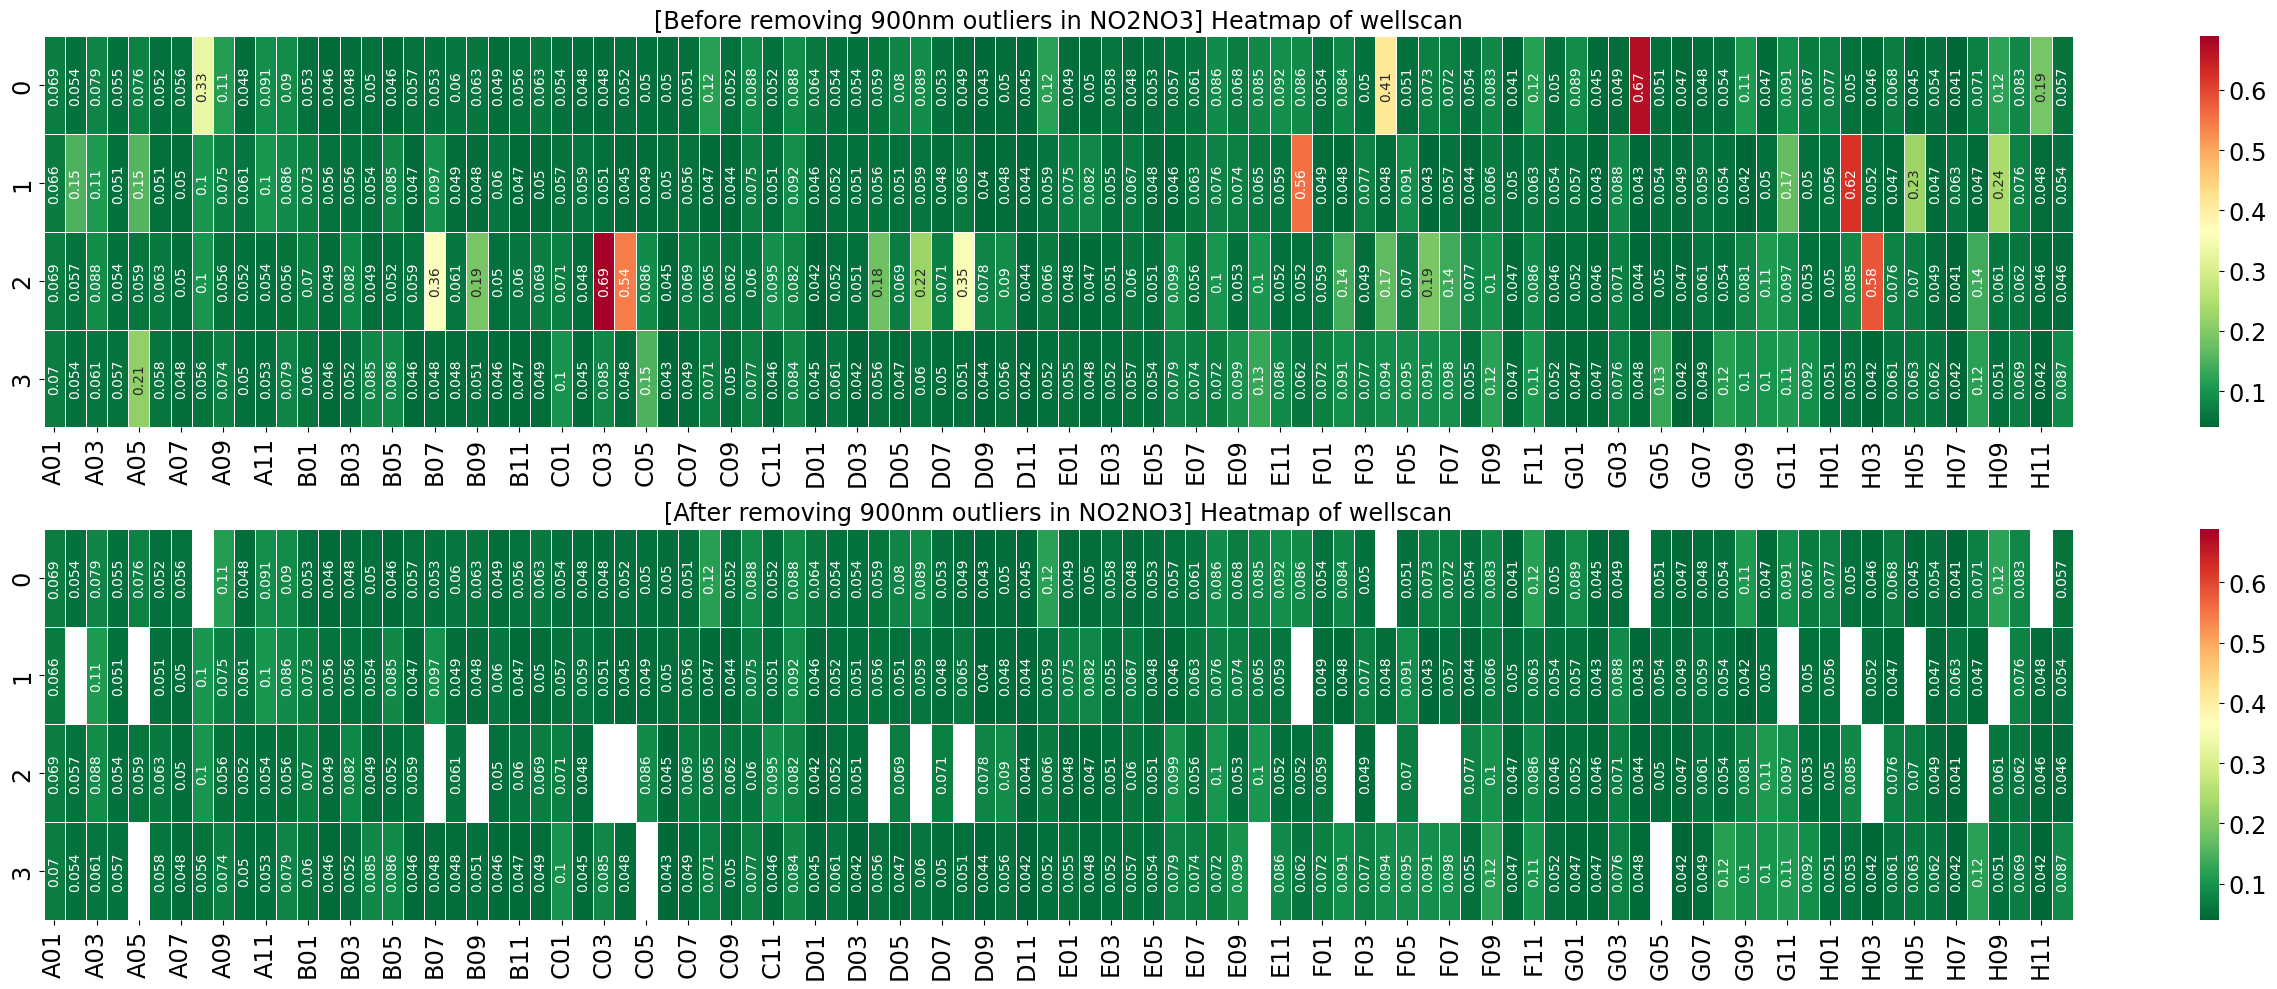

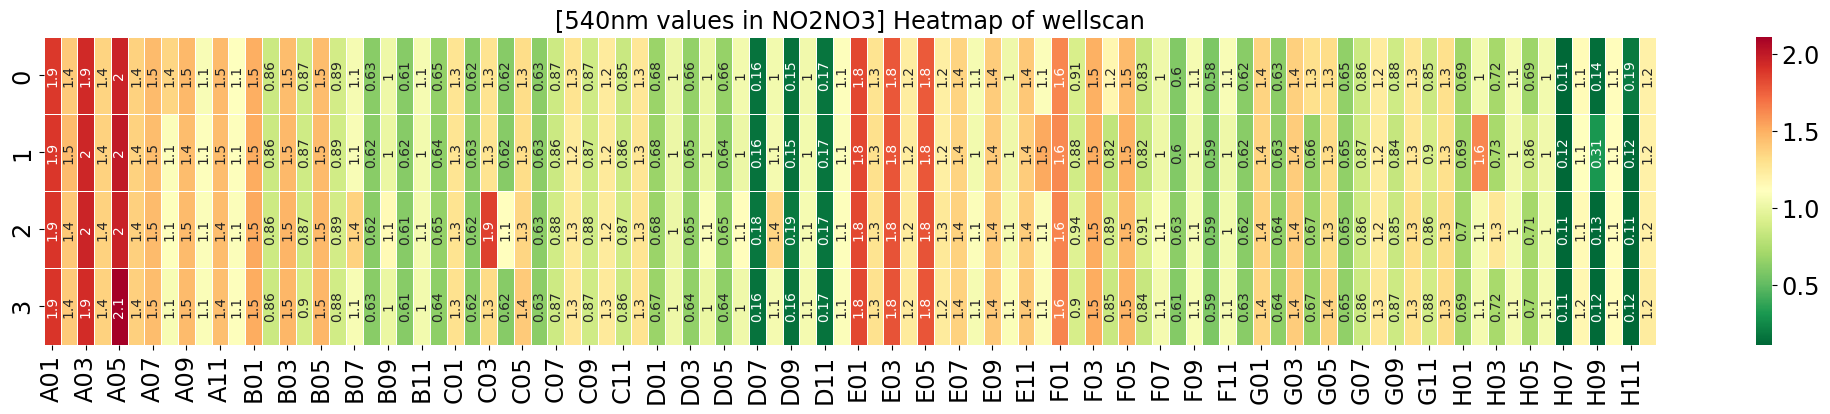

20241103/sample_metadata.csv
Before subtracting blank value
returns true for elements more than 1.5 interquartile ranges above the upper quartile
A01    1.910740
A02    2.062282
A03    2.003975
A04    2.025522
A05    2.064490
         ...   
H08    0.080780
H09    0.073120
H10    0.067801
H11    0.071579
H12    0.068551
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1.5 interquartile ranges above the upper quartile
A01    1.89055
A02    1.40000
A03    1.94310
A04    1.36430
A05    1.96365
        ...   
H08    1.13870
H09    0.12670
H10    1.12175
H11    0.11560
H12    1.20560
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.851737
A02    0.925210
A03    0.896874
A04    0.907336
A05    0.926284
         ...   
H08    0.004929
H09    0.001527
H10    0.000000
H11    0.000843
H12    0.000000
Name: NO2_mM, Length: 96, dtype: float64
A01    1.699476
A02    1.124892
A03    1.771010
A04    1.0879

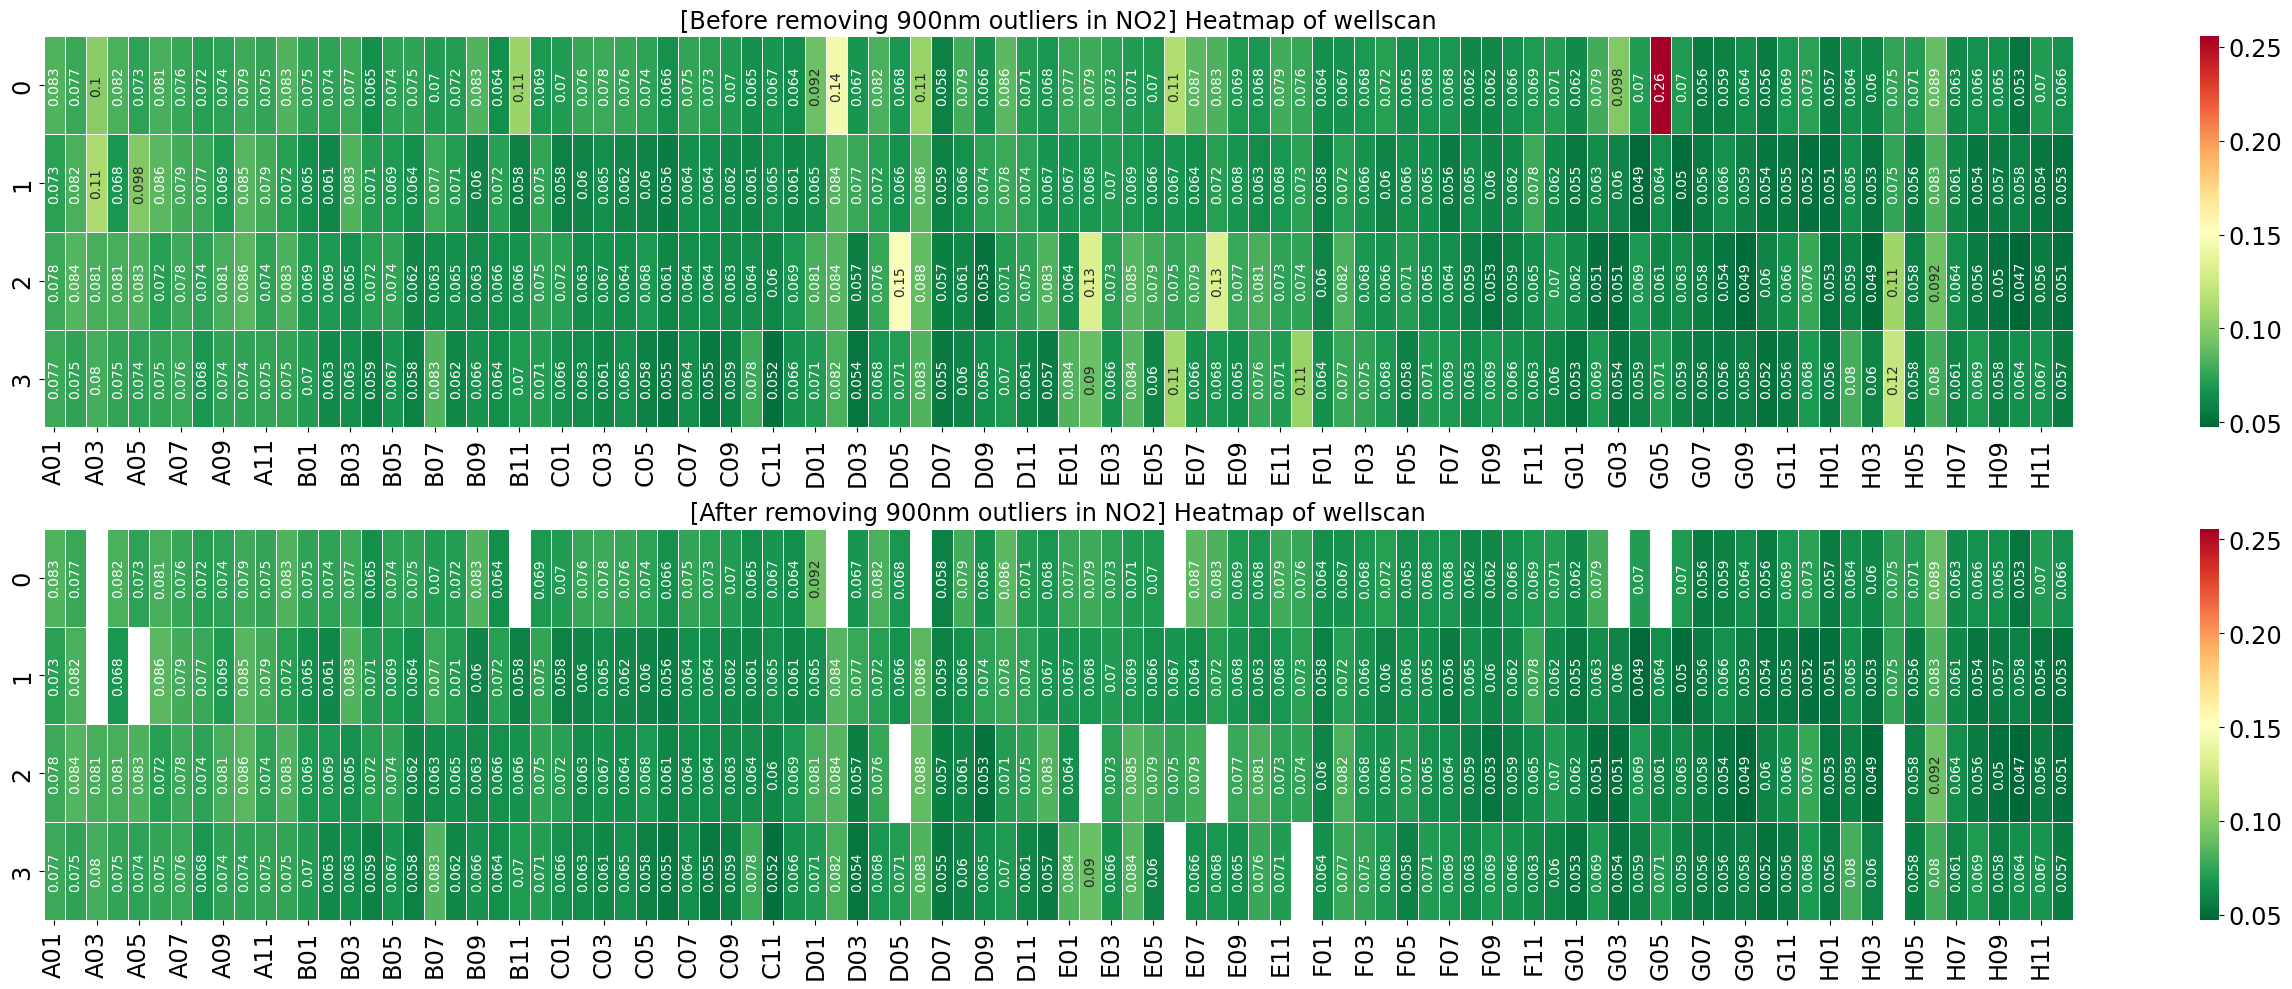

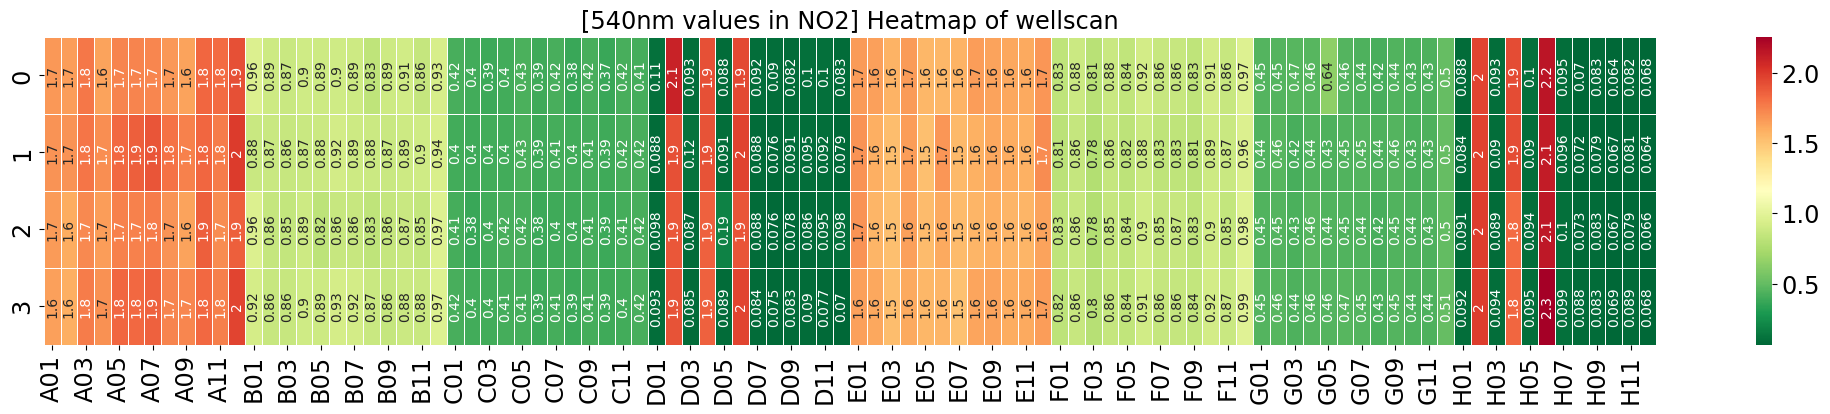

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1.5 interquartile ranges above the upper quartile


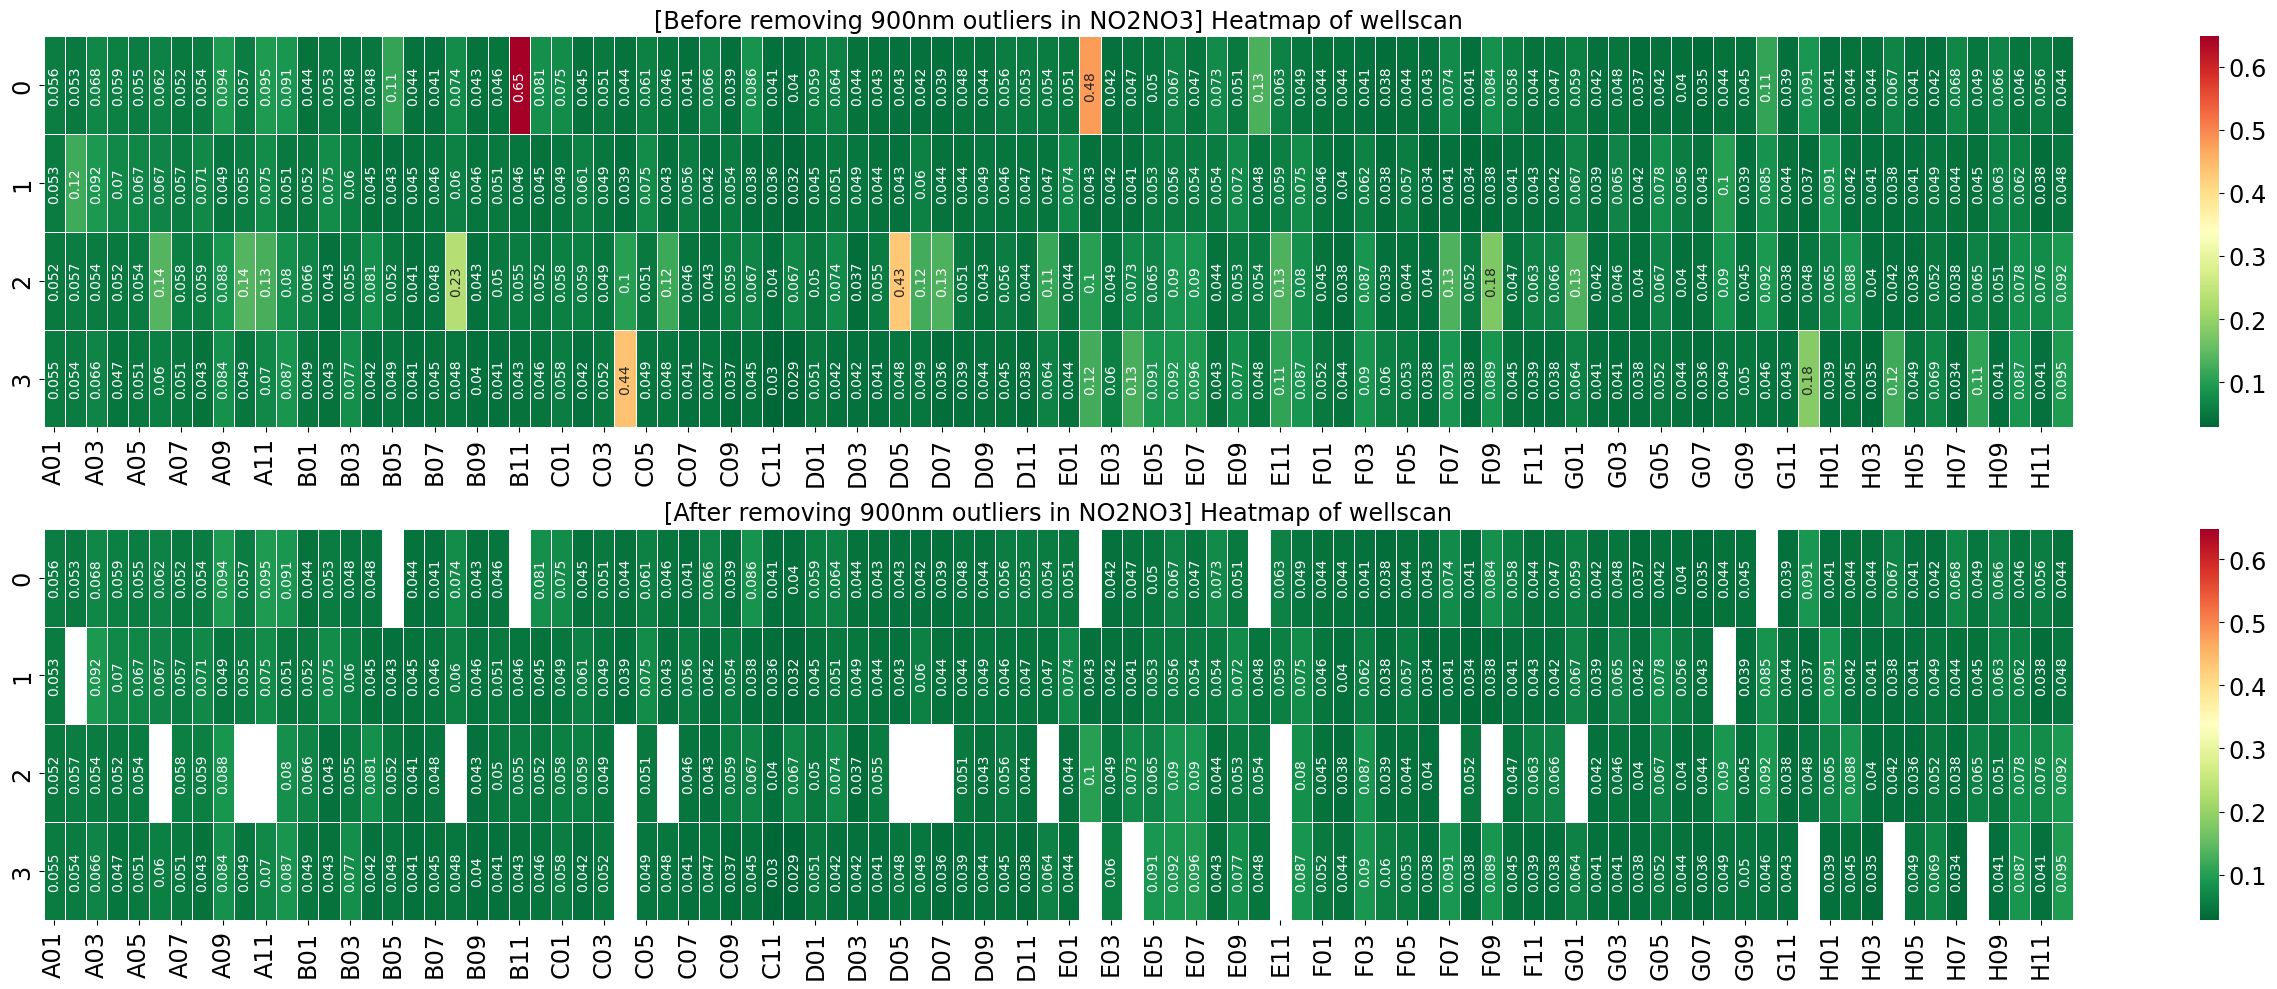

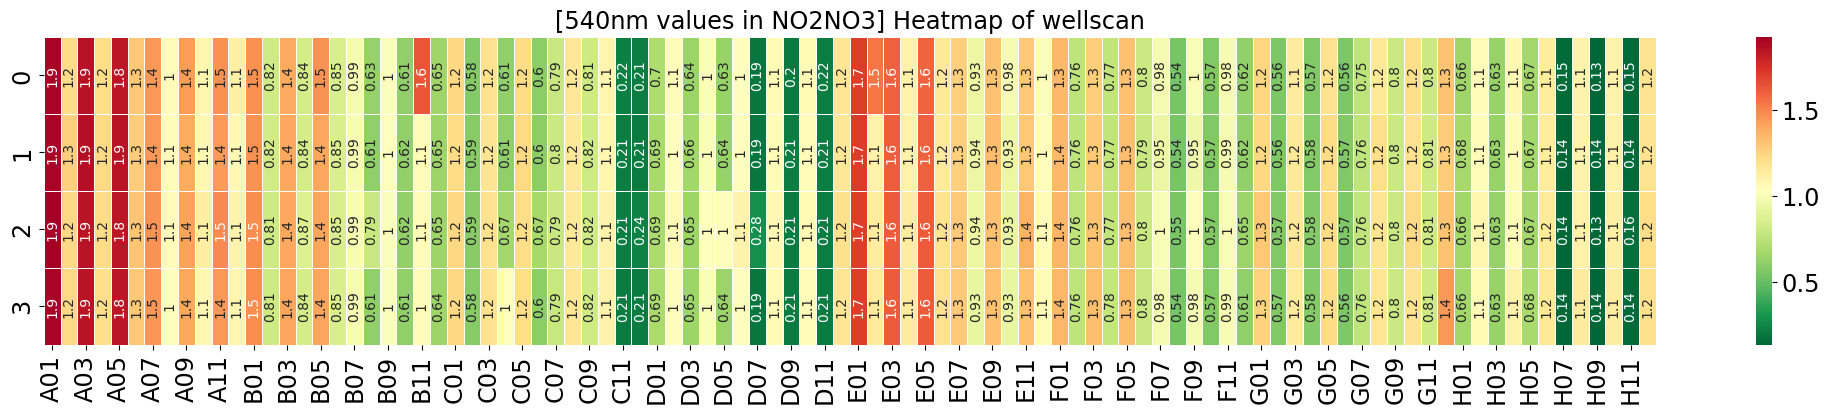

20241103/sample_metadata.csv
Before subtracting blank value
returns true for elements more than 1.5 interquartile ranges above the upper quartile
A01    1.667128
A02    1.627075
A03    1.742458
A04    1.674786
A05    1.749794
         ...   
H08    0.072589
H09    0.082815
H10    0.067097
H11    0.081528
H12    0.067141
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1.5 interquartile ranges above the upper quartile
A01    1.91335
A02    1.22770
A03    1.85985
A04    1.21890
A05    1.84735
        ...   
H08    1.10280
H09    0.13465
H10    1.11610
H11    0.14370
H12    1.19680
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.734782
A02    0.715687
A03    0.770797
A04    0.738437
A05    0.774312
         ...   
H08    0.001291
H09    0.005833
H10    0.000000
H11    0.005261
H12    0.000000
Name: NO2_mM, Length: 96, dtype: float64
A01    1.730198
A02    0.951153
A03    1.658830
A04    0.9425

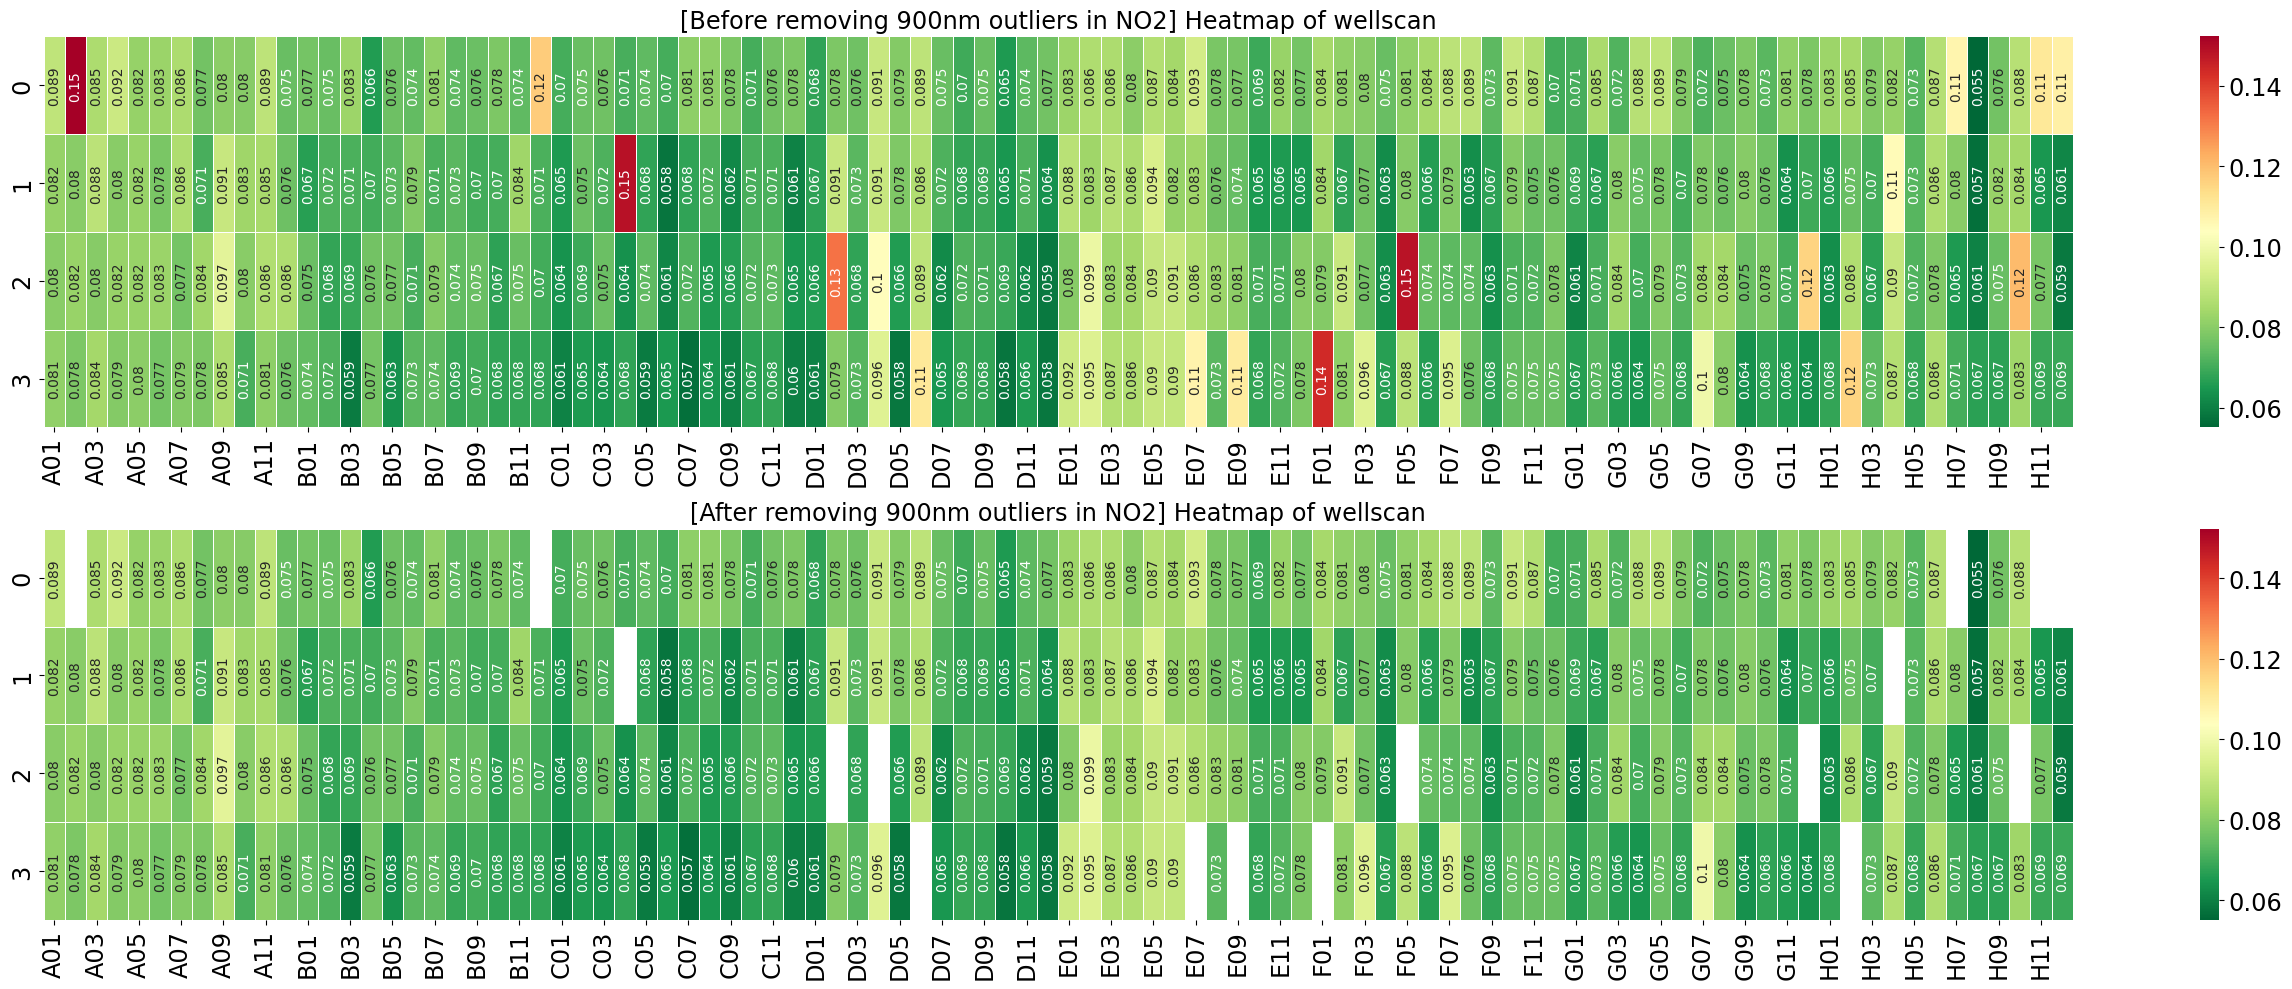

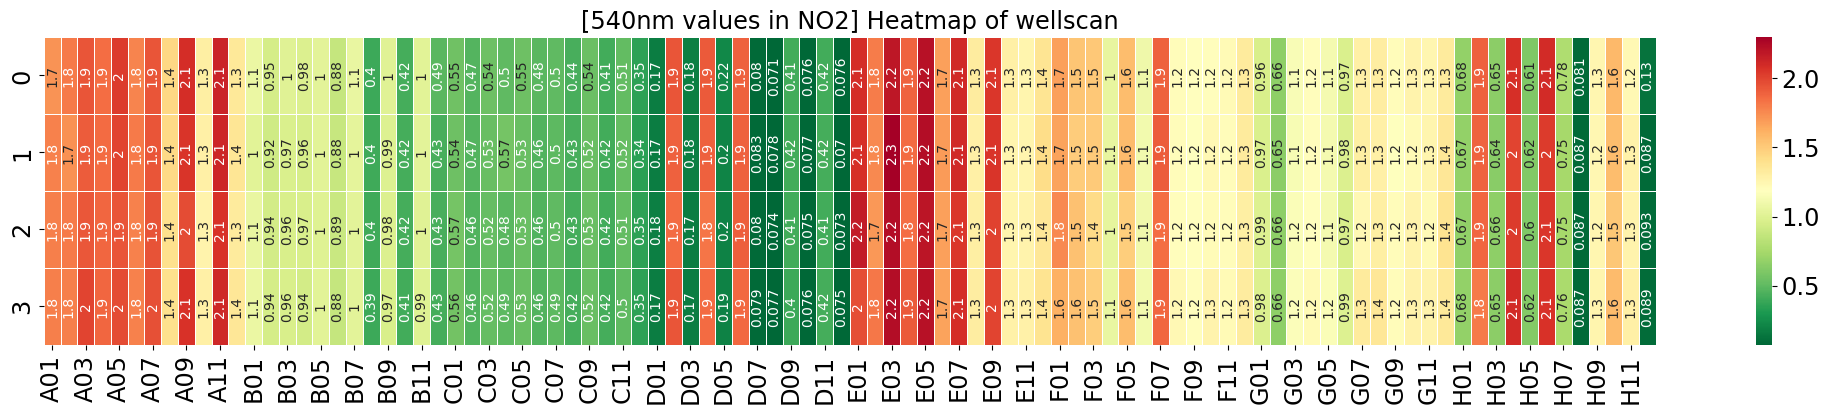

-----------------------
Check wellscan for outlier removal in NO2NO3


IndexError: list index out of range

In [15]:
%pip install openpyxl

for i in [0,1,2,3,4,5,6,7,8]:
    AW_plate1_2_T0_meta_fn = "20241103/sample_metadata.csv"
    print(AW_plate1_2_T0_meta_fn)
    AW_plate1_2_T0_no2_fn = None
    print(AW_plate1_2_T0_no2_fn)
    AW_plate1_2_T0_no2_540_fn = glob.glob(f"20241103/*_NO2_tp{i}_540*")[0]
    print(AW_plate1_2_T0_no2_540_fn)
    AW_plate1_2_T0_no2_900_fn = glob.glob(f"20241103/*_NO2_tp{i}_900*")[0]
    print(AW_plate1_2_T0_no2_900_fn)
    AW_plate1_2_T0_no2no3_fn = None
    print(AW_plate1_2_T0_no2no3_fn)
    AW_plate1_2_T0_no2no3_540_fn = glob.glob(f"20241103/*_NO2NO3_tp{i}_540*")[0]
    print(AW_plate1_2_T0_no2no3_540_fn)
    AW_plate1_2_T0_no2no3_900_fn = glob.glob(f"20241103/*_NO2NO3_tp{i}_900*")[0]
    print(AW_plate1_2_T0_no2no3_900_fn)

    gr.get_concentration_xlsx(excel_output = f"20241103/griess_{i}.xlsx",
                                no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, 
                            meta_fn = AW_plate1_2_T0_meta_fn, no2_fn=None, no2_540_fn = AW_plate1_2_T0_no2_540_fn, no2_900_fn = AW_plate1_2_T0_no2_900_fn, no2no3_fn=None, no2no3_540_fn=AW_plate1_2_T0_no2no3_540_fn, no2no3_900_fn=AW_plate1_2_T0_no2no3_900_fn)
    
    print("--------------------------------------------------------------------------------------------------------------")

        